# WC26 Qualifier & Friendly History — Analysis

Starter notebook for the dataset produced by `scrape_history.py`:
real qualifier and friendly matches (last ~12 months) for the 48 WC26
teams, scraped from ESPN the same way as `scrape_wc26.py` — no
synthetic rows.

This data feeds the **Predictor's** player ratings only (see
`backend/app/data.py:_load_predictor_inputs`) — it never touches
Match Analysis, Player Analysis, or Overview. This notebook is purely
for understanding/exploring it; nothing here writes back to the app.

Re-run top to bottom after `make history` pulls a fresh window.

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

DATA = Path("data")
df = pd.read_parquet(DATA / "historical_form.parquet")
glossary = pd.read_csv(DATA / "glossary.csv")
squads = json.loads((DATA / "squads_raw.json").read_text())
wc26_team_ids = {s["team_id"] for s in squads}

# Numeric columns occasionally arrive as strings — same coercion data.py does.
ID_COLS = {
    "game_id", "match_date", "competition", "season", "team_id", "team_name",
    "home_away", "is_winner", "formation", "team_score", "opp_team_id",
    "opp_team_name", "opp_score", "player_id", "player_name", "jersey",
    "position", "position_abbr", "starter", "subbed_in", "subbed_out",
    "minutes", "appearances", "scraped_at",
}
for c in df.columns:
    if c not in ID_COLS:
        df[c] = pd.to_numeric(df[c], errors="coerce")
df["minutes"] = pd.to_numeric(df["minutes"], errors="coerce").fillna(0)

# This is the exact filter backend/app/data.py applies before it ever
# reaches the Predictor — keep only the WC26 side's rows, drop their
# (often non-WC26) opponents.
wc26 = df[df["team_id"].astype(str).isin(wc26_team_ids)].copy()

print(f"All rows (incl. opponents): {len(df):,} | games: {df['game_id'].nunique()} | teams: {df['team_name'].nunique()}")
print(f"WC26-side rows only:        {len(wc26):,} | players: {wc26['player_id'].nunique()} | teams: {wc26['team_name'].nunique()} / 48")
print(f"Date range: {df['match_date'].min()} -> {df['match_date'].max()}")

All rows (incl. opponents): 11,083 | games: 332 | teams: 148
WC26-side rows only:        7,141 | players: 1856 | teams: 48 / 48
Date range: 2025-07-24T12:00Z -> 2026-06-07T00:00Z


## Glossary lookup

Same helper as `analysis.ipynb` — every stat column mapped to its human
name, category and on-page abbreviation.

In [2]:
def describe(*cols):
    """Show glossary rows for the given stat column name(s)."""
    return glossary[glossary.column.isin(cols)][
        ["column", "name", "abbreviation", "category", "description"]
    ]

describe("expectedGoals", "expectedAssists", "totalTackles")

,column,name,abbreviation,category,description
14,totalTackles,totalTackles,TOT,defensive,The number of tackles attempted.
92,expectedAssists,expectedAssists,xA,offensive,Total Expected Assists
95,expectedGoals,expectedGoals,xG,offensive,Total expected goals


## Coverage by competition

How many games came from each confederation's qualifiers vs friendlies.

,games
competition,
International Friendly,166
FIFA World Cup Qualifying - UEFA,91
FIFA World Cup Qualifying - CAF,40
FIFA World Cup Qualifying - Concacaf,18
FIFA World Cup Qualifying - CONMEBOL,10
FIFA World Cup Qualifying - AFC,7


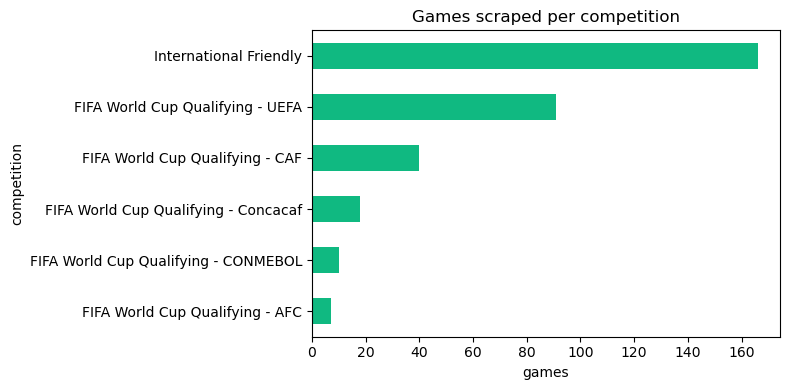

In [3]:
by_comp = (
    df.drop_duplicates("game_id")
      .groupby("competition")["game_id"]
      .nunique()
      .sort_values(ascending=False)
)
display(by_comp.to_frame("games"))

by_comp.plot(kind="barh", figsize=(8, 4), color="#10b981")
plt.gca().invert_yaxis()
plt.xlabel("games")
plt.title("Games scraped per competition")
plt.tight_layout()
plt.show()

## How much historical signal does each WC26 team actually have?

Total minutes (across all their players combined) accumulated in this
window — teams low on this list are the ones the Predictor still has
little real data for outside the tournament itself.

,games,total_minutes
team_name,,
Mexico,13,12870.0
Panama,12,11883.0
Czechia,10,10562.0
Bosnia-Herzegovina,10,10560.0
Senegal,10,10214.0
Australia,10,9900.0
Ghana,10,9900.0
Germany,10,9900.0
New Zealand,10,9889.0


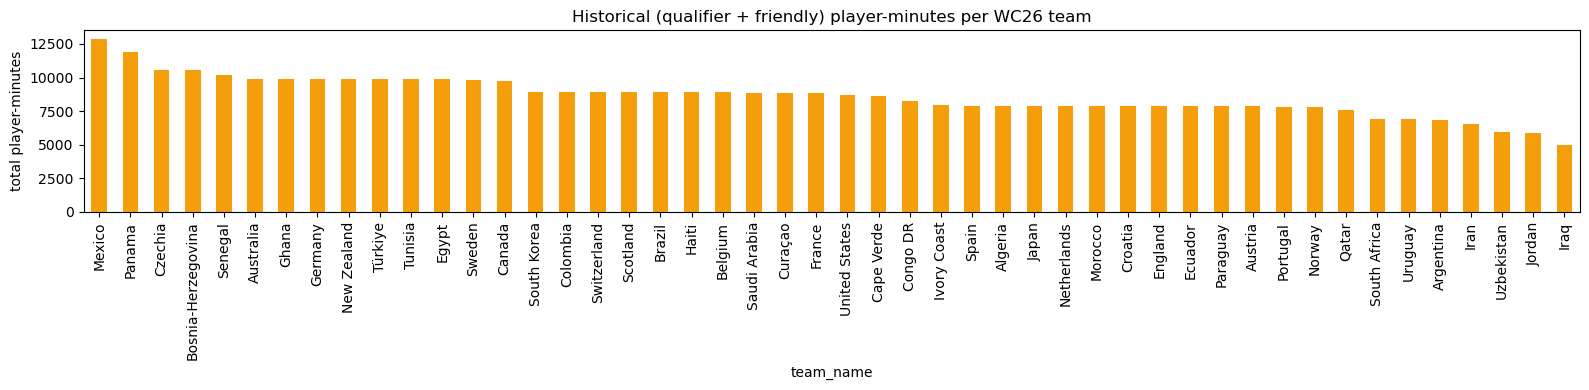

In [4]:
team_minutes = (
    wc26.groupby("team_name")
        .agg(games=("game_id", "nunique"), total_minutes=("minutes", "sum"))
        .sort_values("total_minutes", ascending=False)
)
display(team_minutes)

team_minutes["total_minutes"].plot(kind="bar", figsize=(16, 4), color="#f59e0b")
plt.ylabel("total player-minutes")
plt.title("Historical (qualifier + friendly) player-minutes per WC26 team")
plt.tight_layout()
plt.show()

## Drill into one team's squad coverage

Change `TEAM_NAME` to inspect exactly what's feeding the Predictor for
any given team — minutes/games per player in this window.

In [5]:
TEAM_NAME = "Argentina"

squad_coverage = (
    wc26[wc26["team_name"] == TEAM_NAME]
        .groupby("player_name")
        .agg(games=("game_id", "nunique"), minutes=("minutes", "sum"))
        .sort_values("minutes", ascending=False)
)
squad_coverage

,games,minutes
player_name,,
Rodrigo De Paul,7,440.0
Emiliano Martínez,5,436.0
Cristian Romero,5,387.0
Nico González,6,383.0
Alexis Mac Allister,6,381.0
Nicolás Tagliafico,5,360.0
Lautaro Martínez,6,346.0
Lionel Messi,4,311.0
Thiago Almada,4,288.0


## Per-90 leaderboards (this window only)

Same per-90 normalisation idea as `analysis.ipynb`, scoped to qualifier/
friendly minutes only — useful to sanity-check the raw signal before it
gets blended with tournament data.

In [6]:
played = wc26[wc26["minutes"] > 0].copy()
agg = played.groupby(["player_id", "player_name", "team_name"]).agg(
    minutes=("minutes", "sum"),
    games=("game_id", "nunique"),
    goals=("totalGoals", "sum"),
    assists=("goalAssists", "sum"),
    xg=("expectedGoals", "sum"),
).reset_index()
agg = agg[agg["minutes"] >= 90]   # at least one full match's worth, for a stable rate
agg["goals_p90"] = (agg["goals"] / agg["minutes"] * 90).round(2)
agg["xg_p90"] = (agg["xg"] / agg["minutes"] * 90).round(2)

print("Top scorers (raw goals, this window):")
display(agg.sort_values("goals", ascending=False).head(10)[
    ["player_name", "team_name", "games", "minutes", "goals", "goals_p90", "xg_p90"]
])

Top scorers (raw goals, this window):


,player_name,team_name,games,minutes,goals,goals_p90,xg_p90
691,Erling Haaland,Norway,5,403.0,13.0,2.90,0.00
500,Mikel Oyarzabal,Spain,7,509.0,8.0,1.41,0.00
152,Sadio Mané,Senegal,7,497.0,8.0,1.45,0.00
1850,Marko Arnautovic,Austria,7,379.0,6.0,1.42,0.00
1356,Mohamed Amoura,Algeria,7,549.0,6.0,0.98,0.05
323,Breel Embolo,Switzerland,8,620.0,6.0,0.87,0.00
43,Kevin De Bruyne,Belgium,7,541.0,6.0,1.00,0.06
362,Mikel Merino,Spain,7,489.0,6.0,1.10,0.00
60,Harry Kane,England,6,456.0,6.0,1.18,0.05
523,Kylian Mbappé,France,7,476.0,6.0,1.13,0.01


## Data-quality sanity check

Minutes should cluster near typical match-share values (subs around
15-30', starters around 90'). A flat/uniform distribution would suggest
a scraping problem.

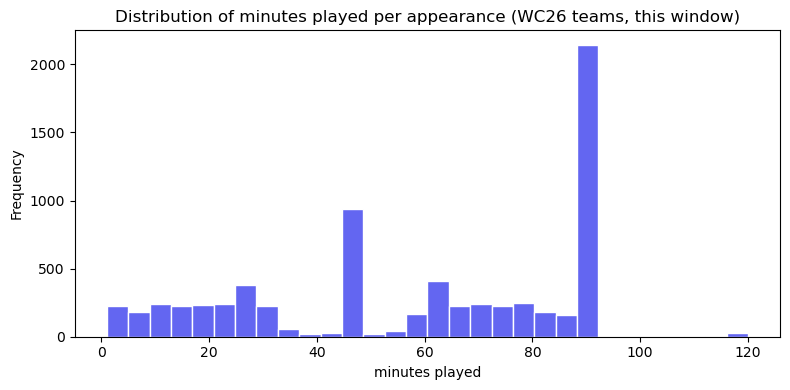

In [7]:
wc26[wc26["minutes"] > 0]["minutes"].plot(
    kind="hist", bins=30, figsize=(8, 4), color="#6366f1", edgecolor="white"
)
plt.xlabel("minutes played")
plt.title("Distribution of minutes played per appearance (WC26 teams, this window)")
plt.tight_layout()
plt.show()

## Your own analysis goes here

`df` (everyone, incl. opponents) and `wc26` (WC26 teams only — same
filter the Predictor uses) are both loaded above. A few ideas:

- Compare a player's qualifier/friendly per-90 rate against their WC26
  tournament rate (load `all_players_stats.parquet` alongside `wc26` and
  join on `player_id`).
- Look at how recent each team's last friendly was before the tournament
  started (`match_date` per team, sorted).
- Check goal-scoring rate by confederation (`groupby("competition")`) to
  see how much the Predictor's `avg_team_goals` baseline shifts once this
  data is blended in.